In [ ]:
# =========================================
# HEART DISEASE DATASET CLEANING & ANALYSIS
# =========================================

# Import Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Libraries
from scipy.stats import pearsonr

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
# na_values=["?"] converts ? into NaN

df = pd.read_csv("heart-2.csv", na_values=["?"])

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Shape
print("Dataset Shape:", df.shape)

# Columns
print("\nColumns:\n", df.columns)

# Data Types
print("\nData Types:\n")
print(df.dtypes)

# Dataset Info
print("\nDataset Info:\n")
print(df.info())

# Statistical Summary
print("\nSummary Statistics:\n")
print(df.describe())

Dataset Shape: (1025, 14)

Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Data Types:

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 no

In [ ]:
# Missing values count
print("Missing Values:\n")
print(df.isna().sum())

# Total missing values
print("\nTotal Missing Values:",
      df.isna().sum().sum())

Missing Values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total Missing Values: 0


In [ ]:
# Categorical columns
cat_cols = ['thal', 'ca']

# Fill categorical missing values using mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],
                   inplace=True)

# Numerical columns
num_cols = ['age',
            'trestbps',
            'chol',
            'thalach',
            'oldpeak']

# Fill numerical missing values using median
for col in num_cols:
    df[col].fillna(df[col].median(),
                   inplace=True)

# Check again
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Duplicate rows
print("Duplicate Rows:",
      df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape After Removing Duplicates:",
      df.shape)

Duplicate Rows: 723
Shape After Removing Duplicates: (302, 14)


In [ ]:
# Negative values check

print("Negative Blood Pressure:",
      (df['trestbps'] < 0).sum())

print("Negative Cholesterol:",
      (df['chol'] < 0).sum())

print("Negative Heart Rate:",
      (df['thalach'] < 0).sum())

# Remove impossible values
df = df[df['trestbps'] > 0]
df = df[df['chol'] > 0]
df = df[df['thalach'] > 0]

print("Final Shape:", df.shape)

Negative Blood Pressure: 0
Negative Cholesterol: 0
Negative Heart Rate: 0
Final Shape: (302, 14)


In [ ]:
# Chest Pain Mapping
cp_map = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
}

df['cp_label'] = df['cp'].map(cp_map)

# Sex Mapping
sex_map = {
    0: 'Female',
    1: 'Male'
}

df['sex_label'] = df['sex'].map(sex_map)

# Fasting Blood Sugar Mapping
fbs_map = {
    0: 'Normal',
    1: 'High'
}

df['fbs_label'] = df['fbs'].map(fbs_map)

# Exercise Angina Mapping
exang_map = {
    0: 'No',
    1: 'Yes'
}

df['exang_label'] = df['exang'].map(exang_map)

# Show dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_label,sex_label,fbs_label,exang_label
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Typical Angina,Male,Normal,No
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Typical Angina,Male,High,Yes
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Typical Angina,Male,Normal,Yes
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Typical Angina,Male,Normal,No
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Typical Angina,Female,High,No


In [ ]:
# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (302, 17)
y Shape: (302,)


In [ ]:
# Numerical columns
numerical_df = df.select_dtypes(
    include=['int64', 'float64']
)

# Correlation matrix
corr_matrix = numerical_df.corr()

# Display
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


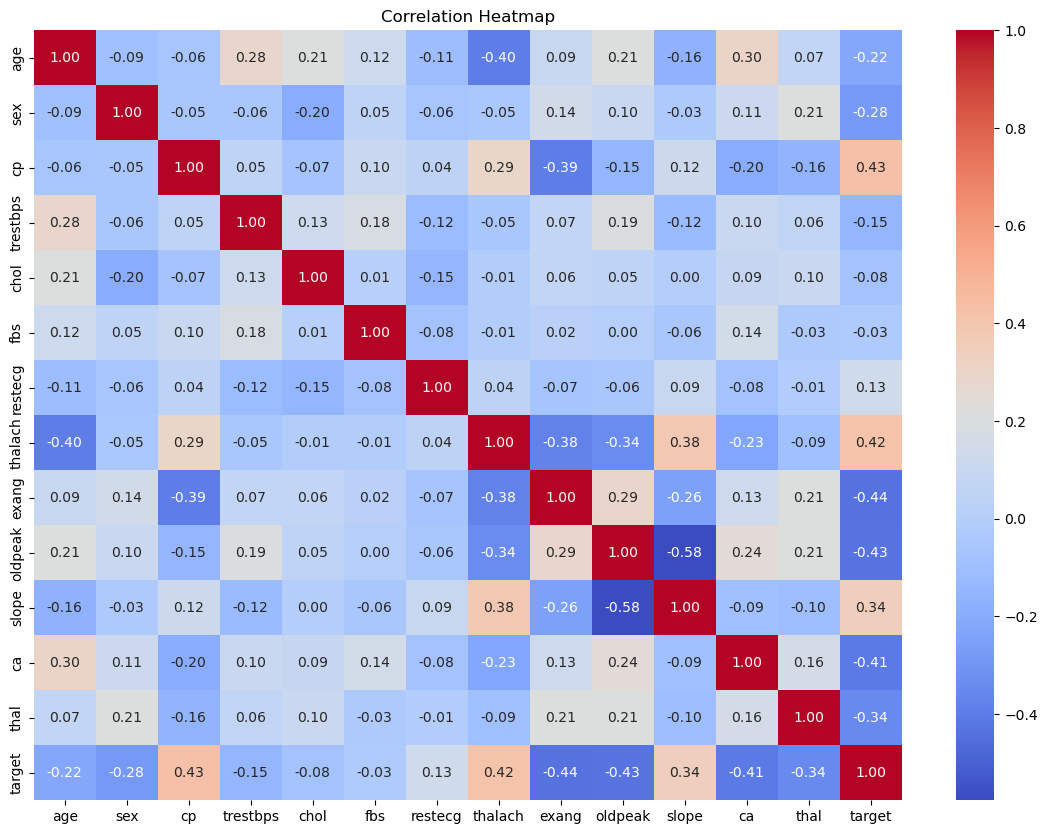

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Empty dataframe
p_values = pd.DataFrame(
    np.zeros((len(numerical_df.columns),
              len(numerical_df.columns))),
    columns=numerical_df.columns,
    index=numerical_df.columns
)

# Calculate p-values
for col1 in numerical_df.columns:
    for col2 in numerical_df.columns:

        corr, p = pearsonr(
            numerical_df[col1],
            numerical_df[col2]
        )

        p_values.loc[col1, col2] = p

# Display p-values
p_values

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,0.000000e+00,9.952665e-02,2.742983e-01,5.661125e-07,0.000288,0.037951,0.052716,9.858304e-13,1.059381e-01,3.127680e-04,4.239560e-03,8.472148e-08,2.578047e-01,1.039484e-04
sex,9.952665e-02,0.000000e+00,3.702482e-01,3.180500e-01,0.000632,0.425517,0.295846,4.213363e-01,1.257250e-02,8.806414e-02,5.679476e-01,4.965426e-02,2.144580e-04,5.402436e-07
cp,2.742983e-01,3.702482e-01,0.000000e+00,4.208583e-01,0.207850,0.095804,0.471790,2.083791e-07,1.367439e-12,1.069559e-02,4.243333e-02,6.406286e-04,5.214549e-03,3.627384e-15
trestbps,5.661125e-07,3.180500e-01,4.208583e-01,0.000000e+00,0.029535,0.001887,0.045152,4.056546e-01,2.351025e-01,6.730550e-04,3.279832e-02,8.509609e-02,2.761081e-01,1.092654e-02
chol,2.883846e-04,6.316749e-04,2.078497e-01,2.953485e-02,0.000000,0.843213,0.010214,9.268014e-01,2.668082e-01,3.857572e-01,9.942467e-01,1.319732e-01,9.308266e-02,1.580370e-01
fbs,3.795116e-02,4.255173e-01,9.580361e-02,1.886588e-03,0.843213,0.000000,0.149783,9.012568e-01,6.686337e-01,9.377288e-01,3.096590e-01,1.168290e-02,5.707363e-01,6.424070e-01
restecg,5.271588e-02,2.958456e-01,4.717904e-01,4.515193e-02,0.010214,0.149783,0.000000,4.755467e-01,2.331887e-01,3.299319e-01,1.169468e-01,1.496286e-01,8.561678e-01,1.903361e-02
thalach,9.858304e-13,4.213363e-01,2.083791e-07,4.056546e-01,0.926801,0.901257,0.475547,0.000000e+00,1.168581e-11,1.011867e-09,4.296438e-12,6.223261e-05,9.971496e-02,2.476146e-14
exang,1.059381e-01,1.257250e-02,1.367439e-12,2.351025e-01,0.266808,0.668634,0.233189,1.168581e-11,0.000000e+00,3.984992e-07,6.556631e-06,2.937709e-02,3.174066e-04,2.046468e-15
oldpeak,3.127680e-04,8.806414e-02,1.069559e-02,6.730550e-04,0.385757,0.937729,0.329932,1.011867e-09,3.984992e-07,0.000000e+00,4.004025e-28,3.281017e-05,2.531393e-04,5.814567e-15


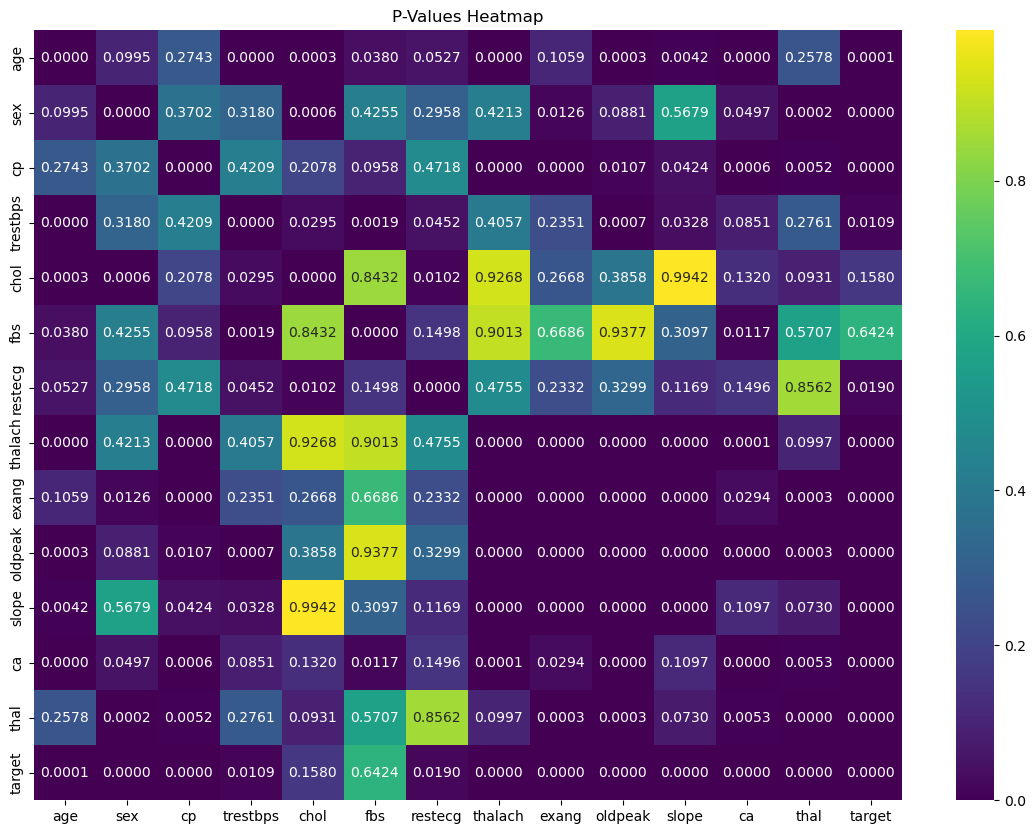

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(p_values,
            annot=True,
            cmap='viridis',
            fmt=".4f")

plt.title("P-Values Heatmap")
plt.show()

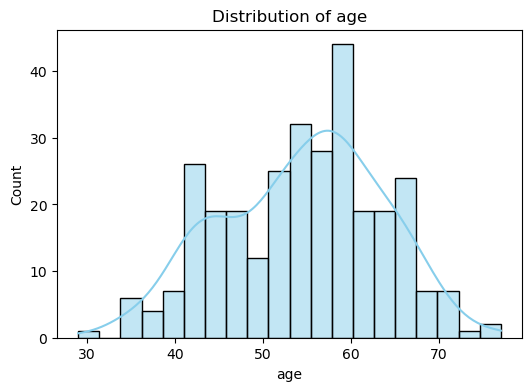

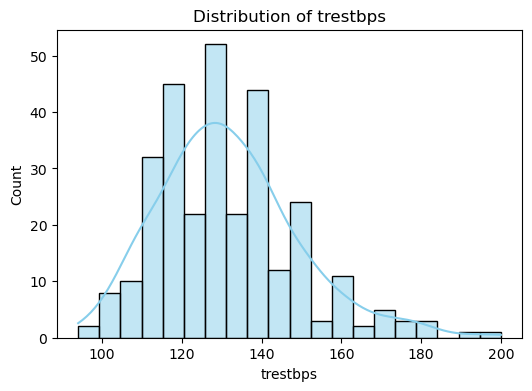

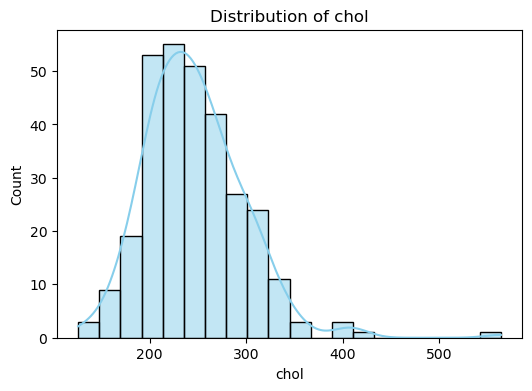

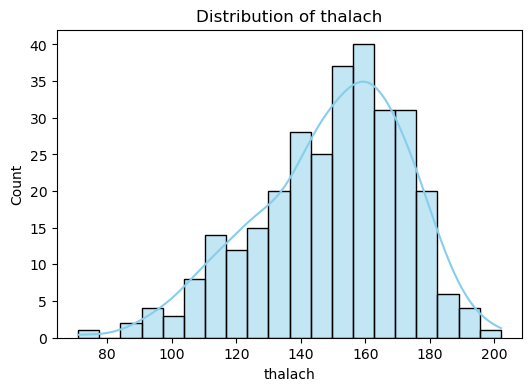

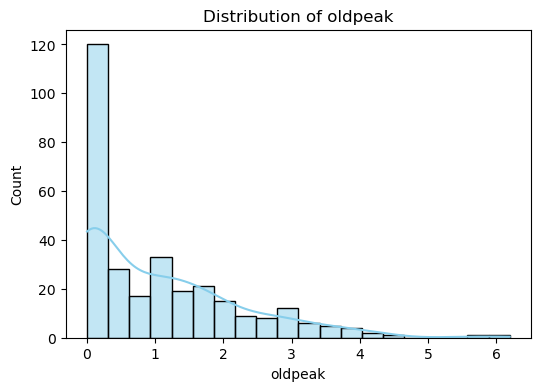

In [ ]:
num_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

for col in num_features:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],
                 kde=True,
                 bins=20,
                 color='skyblue')

    plt.title(f"Distribution of {col}")
    plt.show()

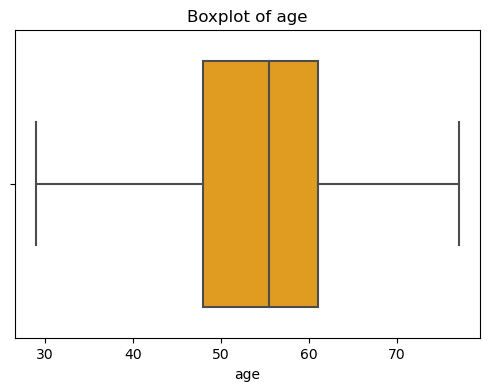

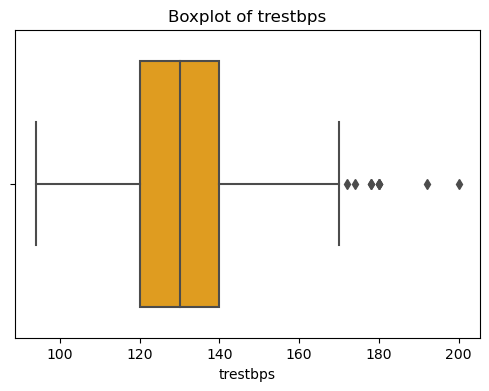

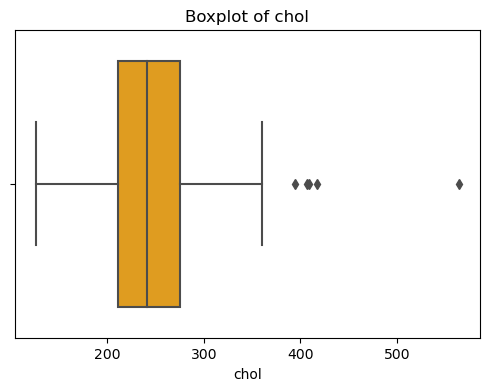

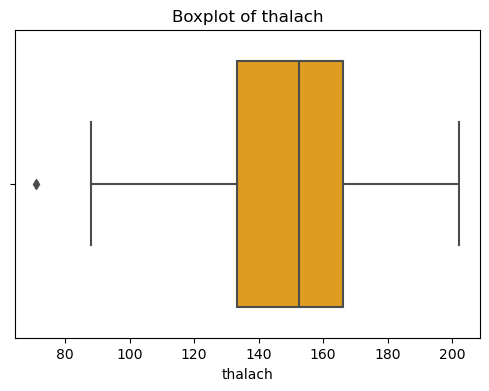

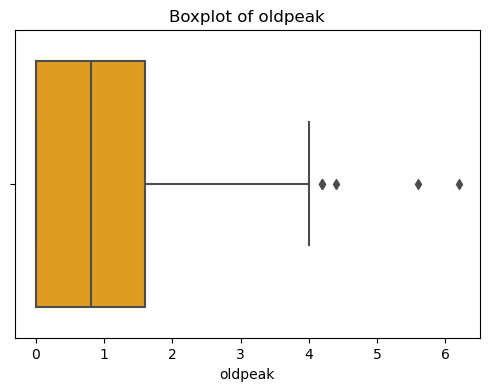

In [ ]:
for col in num_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col],
                color='orange')

    plt.title(f"Boxplot of {col}")
    plt.show()

1    164
0    138
Name: target, dtype: int64


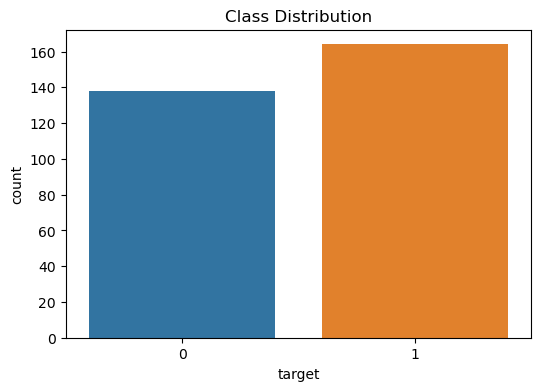

In [ ]:
# Count values
print(df['target'].value_counts())

# Visualization
plt.figure(figsize=(6,4))

sns.countplot(x='target',
              data=df)

plt.title("Class Distribution")
plt.show()

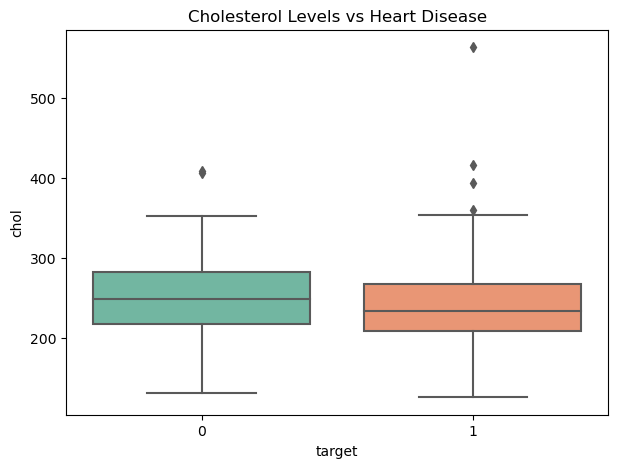

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='target',
    y='chol',
    data=df,
    palette='Set2'
)

plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

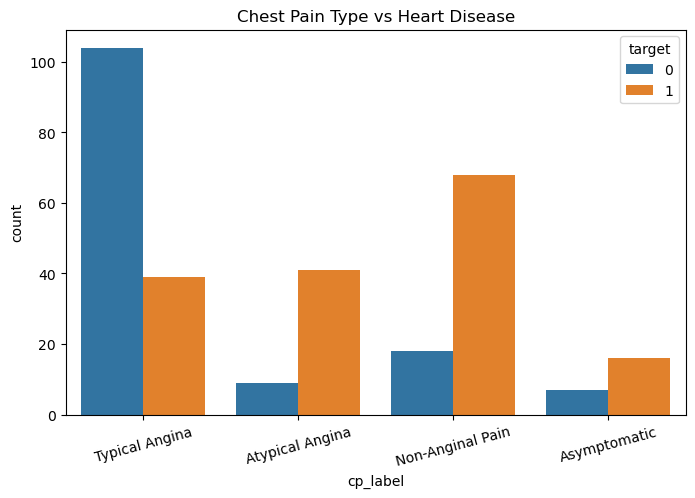

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='cp_label',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=15)
plt.show()

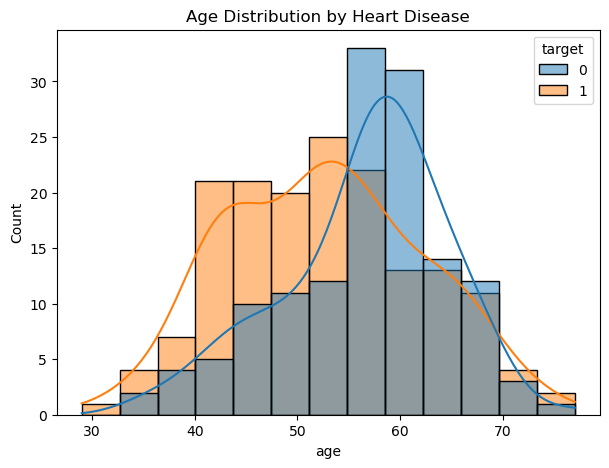

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x='age',
    hue='target',
    kde=True
)

plt.title("Age Distribution by Heart Disease")
plt.show()

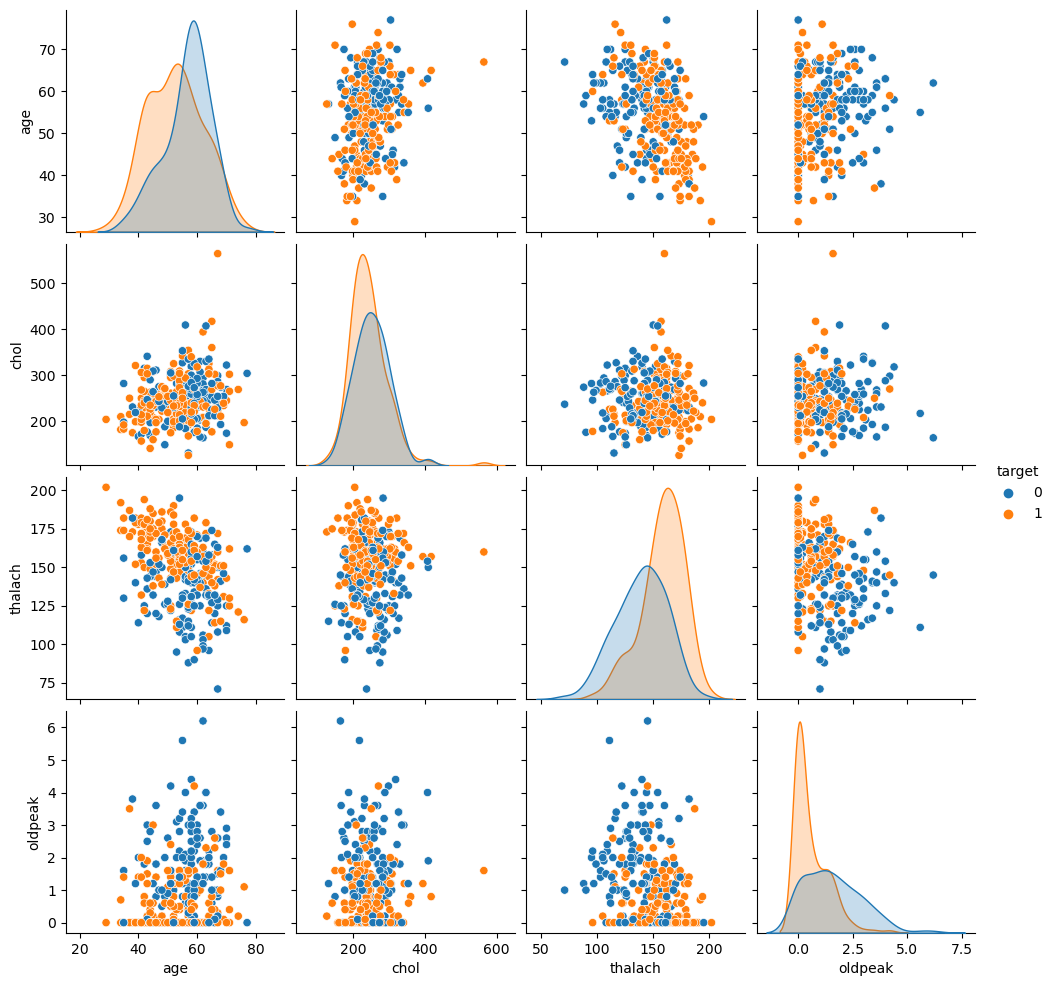

In [ ]:
sns.pairplot(
    df[['age',
        'chol',
        'thalach',
        'oldpeak',
        'target']],
    hue='target'
)

plt.show()

In [ ]:
# Categorical columns
cat_columns = [
    'cp_label',
    'sex_label',
    'fbs_label',
    'exang_label'
]

# One Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=cat_columns,
    drop_first=True
)

# Display
df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_label_Atypical Angina,cp_label_Non-Anginal Pain,cp_label_Typical Angina,sex_label_Male,fbs_label_Normal,exang_label_Yes
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0,0,1,1,1,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0,0,1,1,0,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0,0,1,1,1,1
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0,0,1,1,1,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0,0,1,0,0,0


In [ ]:
# Save cleaned dataset
df_encoded.to_csv(
    "cleaned_heart_disease.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [ ]:
corr_matrix.to_csv(
    "correlation_matrix.csv"
)

p_values.to_csv(
    "p_values_matrix.csv"
)

print("Files Saved Successfully!")

Files Saved Successfully!


Medical Data Quality

Medical data quality is very important because incorrect or missing
patient information can lead to wrong diagnoses and treatment.
Machine learning models depend on accurate data to make reliable
predictions in healthcare systems.

Missing Values Handling

Missing values can reduce model accuracy and create biased predictions.
Using techniques like mode and median imputation helps preserve
important information and improves dataset quality.

Numeric Codes VS Descriptive Lables

Many healthcare datasets use numeric codes to represent categories.
Converting codes into descriptive labels improves readability,
interpretability, and helps healthcare professionals understand
the dataset more effectively.